In [3]:
import warnings
warnings.filterwarnings("ignore")

In [47]:
import glob
import math
import os
import sys
import time
import traceback
import numpy as np
import pandas as pd
from persim import wasserstein
from ripser import ripser
from scipy import stats
import xgboost as xgb
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

## **Step 1**

- after loading dataset, we fix the date index by using the real dates from column unnamed: 0
- so that the rows follow the real market calendar
- a small check was added to drop tickers that have too few valid rows in `z`  
- this stops bad tickers from creating broken windows or NaNs later  
- clean dates and clean tickers here help the later steps (windowing, correlation, tda) run smoothly  

In [8]:
path = r"C:\Users\91829\Downloads\tml\curated_multi_1990_2020.csv"

df_raw = pd.read_csv(path, low_memory=False)
if "Unnamed: 0" in df_raw.columns:
    df_raw["Date"] = pd.to_datetime(df_raw["Unnamed: 0"], errors="coerce")
    df_raw = df_raw.drop(columns=["Unnamed: 0"])
else:
    if "Date" in df_raw.columns:
        df_raw["Date"] = pd.to_datetime(df_raw["Date"], errors="coerce")
    else:
        raise RuntimeError("Cannot find date column")

df_raw = df_raw.set_index("Date").sort_index()

print("Loaded df_raw shape:", df_raw.shape)
print("Date range:", df_raw.index.min(), "to", df_raw.index.max())
print("Rows all-NaN (raw):", int(df_raw.isna().all(axis=1).sum()))

df = df_raw.dropna(how="all").copy()
print("After dropping all-NaN rows shape:", df.shape)

na_frac_pre = df.isna().mean().sort_values(ascending=False)
num_gt5 = int((na_frac_pre > 0.05).sum())
print("Tickers with >5% NA (pre-ffill):", num_gt5)

tickers_to_keep_pre = na_frac_pre[na_frac_pre <= 0.05].index.tolist()
print("Tickers kept (pre-ffill <=5% NA):", len(tickers_to_keep_pre))

df = df[tickers_to_keep_pre].copy()
print("Shape after dropping >5%-NA tickers:", df.shape)

df = df.ffill()

fully_pop_mask = (~df.isna()).all(axis=1)
if fully_pop_mask.any():
    first_full_date = fully_pop_mask[fully_pop_mask].index[0]
else:
    first_full_date = None
print("Earliest fully-populated date after ffill:", first_full_date)

fallback = pd.to_datetime("1990-01-16")
if first_full_date is not None:
    df = df.loc[first_full_date:].copy()
else:
    print("WARNING no fully-populated date found after ffill")
    df = df.loc[fallback:].copy()

print("Shape after truncation:", df.shape)

bd_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="B")
df = df.reindex(bd_index)
df = df.ffill()
print("Shape after reindex to business days:", df.shape)
print("Any remaining all-NaN rows?:", int(df.isna().all(axis=1).sum()))

df = df.astype(float)
logp = np.log(df)
logr = logp.diff().dropna(how="all")
print("logp shape:", logp.shape, "logr shape:", logr.shape)

window = 60
roll_mean = logr.rolling(window=window, min_periods=window).mean()
roll_std  = logr.rolling(window=window, min_periods=window).std()

z = (logr - roll_mean) / roll_std
z_dropna_any = z.dropna(how="any")
print("z (before dropna) shape:", z.shape)
print("z (after dropna any) shape:", z_dropna_any.shape)

def try_remediation(current_df, current_tick_list):
    df_local = current_df.copy()
    tickers = list(current_tick_list)
    iteration = 0
    while True:
        iteration += 1
        logp_local = np.log(df_local.astype(float))
        logr_local = logp_local.diff().dropna(how="all")
        roll_mean_local = logr_local.rolling(window=window, min_periods=window).mean()
        roll_std_local  = logr_local.rolling(window=window, min_periods=window).std()
        z_local = (logr_local - roll_mean_local) / roll_std_local
        z_local_clean = z_local.dropna(how="any")
        print(f"Remediation iter {iteration}: df shape {df_local.shape}, logr {logr_local.shape}, z_clean {z_local_clean.shape}")
        if z_local_clean.shape[0] >= 60:
            return df_local, z_local_clean, tickers, iteration
        cols_with_nan = logr_local.columns[logr_local.isna().any()].tolist()
        if not cols_with_nan:
            print("No columns with NaNs in logr and z still <60 rows")
            return df_local, z_local_clean, tickers, iteration
        cols_to_remove = cols_with_nan
        print(f"Removing {len(cols_to_remove)} tickers that cause NaNs in logr")
        tickers = [t for t in tickers if t not in cols_to_remove]
        df_local = df_local[tickers].copy()
        if len(tickers) < 50:
            print("Ticker count below 50 stopping remediation")
            return df_local, z_local_clean, tickers, iteration

if z_dropna_any.shape[0] < 60:
    print("z has fewer than 60 rows, attempting remediation")
    df_remed, z_remed, tickers_after, iters = try_remediation(df, df.columns.tolist())
    print("Remediation completed in", iters, "iterations")
    print("Tickers remaining:", len(tickers_after))
    print("Final z shape:", z_remed.shape)
    z_final = z_remed
    df_final = df_remed
else:
    print("Strict processing produced enough rows")
    z_final = z_dropna_any
    df_final = df

print("----- FINAL DIAGNOSTICS -----")
print("Tickers kept:", df_final.shape[1])
print("Rows in z_final:", z_final.shape[0])
print("z_final shape:", z_final.shape)
print("First 5 rows of z_final:")
print(z_final.iloc[:5, :10])
print("Last 5 rows of z_final:")
print(z_final.iloc[-5:, :10])

z_final.to_csv("standardized_returns_z.csv")
logr.to_csv("log_returns.csv")
pd.Series(df_final.columns.tolist(), name="tickers_kept").to_csv("tickers_kept.csv", index=False)
print("Saved standardized_returns_z.csv, log_returns.csv, and tickers_kept.csv")


Loaded df_raw shape: (8089, 394)
Date range: 1990-01-01 00:00:00 to 2020-12-31 00:00:00
Rows all-NaN (raw): 278
After dropping all-NaN rows shape: (7811, 394)
Tickers with >5% NA (pre-ffill): 164
Tickers kept (pre-ffill <=5% NA): 230
Shape after dropping >5%-NA tickers: (7811, 230)
Earliest fully-populated date after ffill: 1991-06-21 00:00:00
Shape after truncation to first usable date: (7439, 230)
Shape after reindex to business days + ffill: (7704, 230)
Any remaining all-NaN rows?: 0
logp shape: (7704, 230) logr shape: (7703, 230)
z (before dropna) shape: (7703, 230)
z (after dropna any) shape: (7644, 230)
Strict processing produced sufficient z rows.
----- FINAL DIAGNOSTICS -----
Tickers kept: 230
Rows in z_final: 7644
z_final shape: (7644, 230)
First 5 rows of z_final:
                IDXX       AZO      REGN        LH      CSCO        PH  \
1991-09-13  1.117311 -0.299445  0.207934 -1.197319 -1.133282 -2.988210   
1991-09-16 -0.908394  1.009598 -0.565531 -1.500000 -1.252824  1.890

## **Step 2:** sliding windows

- so now, we use the standardized return matrix from step 1  
- slide a 60-day window across the data with step = 1  
- keep only windows that have exactly 60 rows and no missing values
- to build 60 day sliding windows
- record each window’s start date, end date, and the 60×N return block  
- save windows in batches (~200 per file) to avoid memory issues  
- and store an index file mapping each window to its batch location  
- ensures fixed-length, complete inputs for correlation matrices  
- keeps tda computations stable since vr complexes need consistent point clouds  
- batching makes later correlation and persistence computations scalable  



In [9]:
def create_windows_and_save(z_csv_path, out_dir="windows_batches", window_size=60, step=1, batch_size=200):
    z = pd.read_csv(z_csv_path, index_col=0, parse_dates=True)
    if not z.index.is_monotonic_increasing:
        z = z.sort_index()
    n_rows, n_cols = z.shape
    starts = []
    ends = []
    batch_windows = []
    batch_meta = []
    os.makedirs(out_dir, exist_ok=True)
    batch_id = 0
    pos_in_batch = 0
    window_index = 0
    for i in range(0, n_rows - window_size + 1, step):
        window = z.iloc[i : i + window_size].values
        if window.shape[0] != window_size:
            raise ValueError("window length mismatch")
        if np.isnan(window).any():
            raise ValueError(f"NaN detected in window starting at {z.index[i].strftime('%Y-%m-%d')}")
        batch_windows.append(window.astype(np.float64))
        starts.append(z.index[i])
        ends.append(z.index[i + window_size - 1])
        batch_meta.append((window_index, z.index[i].strftime("%Y-%m-%d"), z.index[i + window_size - 1].strftime("%Y-%m-%d")))
        pos_in_batch += 1
        window_index += 1
        if pos_in_batch >= batch_size:
            windows_arr = np.stack(batch_windows, axis=0)
            batch_fname = f"windows_batch_{batch_id:04d}.npz"
            np.savez_compressed(os.path.join(out_dir, batch_fname), windows=windows_arr)
            batch_id += 1
            batch_windows = []
            pos_in_batch = 0
    if batch_windows:
        windows_arr = np.stack(batch_windows, axis=0)
        batch_fname = f"windows_batch_{batch_id:04d}.npz"
        np.savez_compressed(os.path.join(out_dir, batch_fname), windows=windows_arr)
    rows = []
    for meta in batch_meta:
        rows.append(meta)
    index_df = pd.DataFrame(rows, columns=["window_index", "start_date", "end_date"])
    index_df.to_csv(os.path.join(out_dir, "windows_index_partial.csv"), index=False)


In [10]:
z_csv_path = "standardized_returns_z.csv"
out_dir = "windows_batches"
window_size = 60
step = 1
batch_size = 200

z = pd.read_csv(z_csv_path, index_col=0, parse_dates=True)
if not z.index.is_monotonic_increasing:
    z = z.sort_index()

n_rows, n_cols = z.shape
total_windows = (n_rows - window_size) // step + 1

os.makedirs(out_dir, exist_ok=True)
batch_id = 0
batch_windows = []
index_rows = []
window_index = 0

for i in range(0, n_rows - window_size + 1, step):
    window_df = z.iloc[i : i + window_size]
    window_arr = window_df.values.astype(np.float64)

    if window_arr.shape[0] != window_size:
        raise RuntimeError("Unexpected window length")
    if np.isnan(window_arr).any():
        raise RuntimeError(f"NaN found in window {window_index} starting {window_df.index[0]}")

    batch_windows.append(window_arr)

    index_rows.append({
        "window_index": window_index,
        "start_date": window_df.index[0].strftime("%Y-%m-%d"),
        "end_date": window_df.index[-1].strftime("%Y-%m-%d"),
        "batch_file": f"windows_batch_{batch_id:04d}.npz",
        "position": len(batch_windows) - 1
    })

    window_index += 1

    if len(batch_windows) >= batch_size:
        arr = np.stack(batch_windows, axis=0)
        batch_path = os.path.join(out_dir, f"windows_batch_{batch_id:04d}.npz")
        np.savez_compressed(batch_path, windows=arr)
        batch_id += 1
        batch_windows = []

if batch_windows:
    arr = np.stack(batch_windows, axis=0)
    batch_path = os.path.join(out_dir, f"windows_batch_{batch_id:04d}.npz")
    np.savez_compressed(batch_path, windows=arr)

index_df = pd.DataFrame(index_rows)
index_csv_path = os.path.join(out_dir, "windows_index.csv")
index_df.to_csv(index_csv_path, index=False)

result = {
    "n_windows": window_index,
    "n_batches": batch_id + (1 if batch_windows==[] and window_index>0 and (window_index % batch_size)==0 else 0),
    "index_csv": index_csv_path
}

print(result)

{'n_windows': 7585, 'n_batches': 37, 'index_csv': 'windows_batches\\windows_index.csv'}


- total of **7585** windows got formed, each covering **60 business days**
- covering the full market period from 1991 to 2020  
- step size was 1 day, so every adjacent window shifts by one row  
- this matches the standardized-return matrix which has **7644 rows**, since  
  7644 − 60 + 1 = 7585 

- windows were saved in batches of about 200 each  
- this produced **37 batches**
- 7585 / 200 ≈ 37.9, so the last batch holds around 185 windows  

- every window had **exactly 60 rows**  
- no missing values were found in any window  
- all windows were successfully saved without shape errors  
- so the returns matrix is stable 
- no broken windows, no missing rows 

## **Step 3**

- in this step, for each 60-day window we compute the pearson correlation across tickers  
- turn each correlation matrix into a euclidean distance matrix using d = sqrt(max(0, 2*(1 - corr)))  
- clip correlation values to avoid small numerical issues and set the diagonal to 1 and distance diagonal to 0  
- fix symmetry so the matrices behave properly later 
- check that every distance matrix is square, symmetric, finite, and has no missing values  
- save all distance matrices in small npz batches to keep memory usage low  
- and at last, make a simple index csv that records which window is stored in which batch file  


In [12]:
EPS = 1e-6
WINDOWS_DIR = Path("windows_batches")
OUT_DIR = Path("corr_batches")
WINDOW_BATCH_PATTERN = "windows_batch_*.npz"
DIST_BATCH_SIZE = 200
OUT_DTYPE = np.float32
SYMM_TOL = 1e-10
DIAG_TOL = 1e-12

os.makedirs(OUT_DIR, exist_ok=True)
windows_index_path = WINDOWS_DIR / "windows_index.csv"
if not windows_index_path.exists():
    raise FileNotFoundError(f"{windows_index_path} not found")
windows_index = pd.read_csv(windows_index_path, parse_dates=["start_date", "end_date"])
window_batch_files = sorted(glob.glob(str(WINDOWS_DIR / WINDOW_BATCH_PATTERN)))
if len(window_batch_files) == 0:
    raise RuntimeError("No window batch files found in windows_batches/")

dist_buffers = []
dist_index_rows = []
global_window_counter = 0
dist_batch_id = 0

for wb_path in window_batch_files:
    wb = np.load(wb_path)
    if "windows" not in wb:
        raise RuntimeError(f"'windows' array missing in {wb_path}")
    windows = wb["windows"]
    n_w = windows.shape[0]
    for pos in range(n_w):
        win = windows[pos]  # shape (60, n_tickers)
        if win.ndim != 2 or win.shape[0] < 2:
            raise RuntimeError(f"Unexpected window shape at global idx {global_window_counter}: {win.shape}")
        corr = np.corrcoef(win, rowvar=False)
        if corr.shape[0] != corr.shape[1]:
            raise RuntimeError(f"Non-square correlation matrix at window {global_window_counter}")
        if np.isnan(corr).any() or not np.isfinite(corr).all():
            raise RuntimeError(f"Invalid correlation matrix (NaN/Inf) at window {global_window_counter}")
        corr = np.clip(corr, -1.0 + EPS, 1.0 - EPS)
        corr = (corr + corr.T) / 2.0
        np.fill_diagonal(corr, 1.0)
        dist = np.sqrt(np.maximum(0.0, 2.0 * (1.0 - corr)))
        if dist.shape[0] != dist.shape[1]:
            raise RuntimeError(f"Non-square distance matrix at window {global_window_counter}")
        if np.isnan(dist).any() or not np.isfinite(dist).all():
            raise RuntimeError(f"Invalid distance matrix (NaN/Inf) at window {global_window_counter}")
        if not np.allclose(dist, dist.T, atol=SYMM_TOL):
            dist = (dist + dist.T) / 2.0
            if not np.allclose(dist, dist.T, atol=1e-8):
                raise RuntimeError(f"Asymmetry persists in distance matrix at window {global_window_counter}")
        if not np.allclose(np.diag(dist), 0.0, atol=DIAG_TOL):
            np.fill_diagonal(dist, 0.0)
        dist_buffers.append(dist.astype(OUT_DTYPE, copy=False))
        idx_row = {
            "window_index": int(global_window_counter),
            "start_date": windows_index.loc[global_window_counter, "start_date"],
            "end_date": windows_index.loc[global_window_counter, "end_date"],
            "batch_file": f"batch_{dist_batch_id:04d}.npz",
            "position": len(dist_buffers) - 1
        }
        dist_index_rows.append(idx_row)
        global_window_counter += 1
        if len(dist_buffers) >= DIST_BATCH_SIZE:
            out_file = OUT_DIR / f"batch_{dist_batch_id:04d}.npz"
            np.savez_compressed(out_file, dists=np.stack(dist_buffers, axis=0))
            dist_batch_id += 1
            dist_buffers = []

if dist_buffers:
    out_file = OUT_DIR / f"batch_{dist_batch_id:04d}.npz"
    np.savez_compressed(out_file, dists=np.stack(dist_buffers, axis=0))
    dist_batch_id += 1

corr_index_df = pd.DataFrame(dist_index_rows)
corr_index_df.to_csv(OUT_DIR / "corr_index.csv", index=False)
summary = {
    "n_distance_windows": int(global_window_counter),
    "n_distance_batches": int(dist_batch_id),
    "corr_index": str(OUT_DIR / "corr_index.csv")
}
print(summary)

{'n_distance_windows': 7585, 'n_distance_batches': 38, 'corr_index': 'corr_batches\\corr_index.csv'}


- **n_distance_windows:** 7585  
- **n_distance_batches:** 38

- the number of distance windows **7585** matches the number of sliding windows produced earlier (7644 − 60 + 1 = 7585).  
- expected number of batches = `ceil(7585 / 200) = 38`

- every 60×N window was without any error converted to a Pearson correlation matrix
- and then to a symmetric distance matrix without NaNs/Inf
- matrices were square and finite).

## **Step 4**

- first, we take each distance matrix from corr_batches and run ripser with maxdim = 1  
- read the h0 and h1 diagrams from the ripser output  
- make simple tda features such as number of long h1 bars, total h1 persistence, and h0 count  
- handle cases where diagrams are empty by filling zeros  
- and finally, create a small index csv that records which window’s tda result is saved in which batch and at which position  

In [16]:
PERSISTENCE_THRESHOLD = 0.01
PD_BATCH_SIZE = 200
CORR_DIR = Path("corr_batches")
OUT_DIR = Path("pd_batches")

def safe_sum_persistence(diagram):
    if diagram.size == 0:
        return 0.0
    lifetimes = diagram[:,1] - diagram[:,0]
    finite_mask = np.isfinite(lifetimes)
    if not finite_mask.any():
        return 0.0
    return float(np.sum(lifetimes[finite_mask]))

def count_long_persistence(diagram, thresh):
    if diagram.size == 0:
        return 0
    lifetimes = diagram[:,1] - diagram[:,0]
    finite_mask = np.isfinite(lifetimes)
    if not finite_mask.any():
        return 0
    return int(np.sum(lifetimes[finite_mask] > thresh))

os.makedirs(OUT_DIR, exist_ok=True)

corr_index_path = CORR_DIR / "corr_index.csv"
if not corr_index_path.exists():
    raise FileNotFoundError(f"{corr_index_path} not found")

corr_index = pd.read_csv(corr_index_path)
batch_files = sorted(glob.glob(str(CORR_DIR / "batch_*.npz")))
if len(batch_files) == 0:
    raise RuntimeError("No distance batch files found in corr_batches/")

pd_batch_id = 0
buffer_window_indices = []
buffer_starts = []
buffer_ends = []
buffer_h1_counts = []
buffer_h1_totals = []
buffer_h0_counts = []
buffer_h1_diags = []
buffer_h0_diags = []
tda_index_rows = []
global_counter = 0

for bf in batch_files:
    arr = np.load(bf)["dists"]
    n_in_batch = arr.shape[0]

    for pos in range(n_in_batch):
        dist = arr[pos]
        if dist.ndim != 2 or dist.shape[0] != dist.shape[1]:
            raise RuntimeError(f"Invalid distance matrix shape at global idx {global_counter}")

        res = ripser(dist, maxdim=1, distance_matrix=True)
        dgms = res.get("dgms", [])

        if len(dgms) < 2:
            dgm0 = np.empty((0,2))
            dgm1 = np.empty((0,2))
        else:
            dgm0 = np.asarray(dgms[0])
            dgm1 = np.asarray(dgms[1])

        h1_total = safe_sum_persistence(dgm1)
        h1_count_long = count_long_persistence(dgm1, PERSISTENCE_THRESHOLD)
        h0_count = dgm0.shape[0]

        buffer_window_indices.append(int(global_counter))
        buffer_starts.append(str(corr_index.loc[global_counter, "start_date"]))
        buffer_ends.append(str(corr_index.loc[global_counter, "end_date"]))
        buffer_h1_counts.append(int(h1_count_long))
        buffer_h1_totals.append(float(h1_total))
        buffer_h0_counts.append(int(h0_count))
        buffer_h1_diags.append(dgm1)
        buffer_h0_diags.append(dgm0)

        tda_index_rows.append({
            "window_index": int(global_counter),
            "start_date": str(corr_index.loc[global_counter, "start_date"]),
            "end_date": str(corr_index.loc[global_counter, "end_date"]),
            "pd_batch_file": f"pd_batch_{pd_batch_id:04d}.npz",
            "position": len(buffer_window_indices) - 1
        })

        global_counter += 1

        if len(buffer_window_indices) >= PD_BATCH_SIZE:
            out_path = OUT_DIR / f"pd_batch_{pd_batch_id:04d}.npz"
            np.savez_compressed(
                out_path,
                window_index=np.array(buffer_window_indices, dtype=np.int32),
                start_date=np.array(buffer_starts, dtype=object),
                end_date=np.array(buffer_ends, dtype=object),
                h1_count_long=np.array(buffer_h1_counts, dtype=np.int32),
                h1_total_persistence=np.array(buffer_h1_totals, dtype=np.float64),
                h0_count=np.array(buffer_h0_counts, dtype=np.int32),
                h1_diagrams=np.array(buffer_h1_diags, dtype=object),
                h0_diagrams=np.array(buffer_h0_diags, dtype=object)
            )

            pd_batch_id += 1
            buffer_window_indices = []
            buffer_starts = []
            buffer_ends = []
            buffer_h1_counts = []
            buffer_h1_totals = []
            buffer_h0_counts = []
            buffer_h1_diags = []
            buffer_h0_diags = []

if buffer_window_indices:
    out_path = OUT_DIR / f"pd_batch_{pd_batch_id:04d}.npz"
    np.savez_compressed(
        out_path,
        window_index=np.array(buffer_window_indices, dtype=np.int32),
        start_date=np.array(buffer_starts, dtype=object),
        end_date=np.array(buffer_ends, dtype=object),
        h1_count_long=np.array(buffer_h1_counts, dtype=np.int32),
        h1_total_persistence=np.array(buffer_h1_totals, dtype=np.float64),
        h0_count=np.array(buffer_h0_counts, dtype=np.int32),
        h1_diagrams=np.array(buffer_h1_diags, dtype=object),
        h0_diagrams=np.array(buffer_h0_diags, dtype=object)
    )
    pd_batch_id += 1

tda_index_df = pd.DataFrame(tda_index_rows)
tda_index_df.to_csv(OUT_DIR / "tda_index.csv", index=False)

summary = {
    "n_tda_windows": int(global_counter),
    "n_pd_batches": int(pd_batch_id),
    "tda_index": str(OUT_DIR / "tda_index.csv")
}

print(summary)

{'n_tda_windows': 7585, 'n_pd_batches': 38, 'tda_index': 'pd_batches\\tda_index.csv'}


In [17]:
df = pd.read_csv("pd_batches/tda_index.csv")
df.shape[0]


7585

## **Step 5**

- in this step we load the h1 diagrams saved inside pd_batches  
- for each window (except the first one) we compare its h1 diagram with the previous one  
- compute the wasserstein-1 distance using persim so we get one number showing how much the topology changed  
- if a diagram is empty, or if ripser gave infinite deaths, we fix those cases by cleaning the diagram or returning 0  
- keep all diagrams in the (k,2) birth–death format so wasserstein does not break  
- save the final wasserstein series in a csv with window_index, dates, and the wasserstein_h1 value  
- this gives a timeline of how fast the market’s loop-structure is changing from one window to the next  
- big spikes here usually mean the correlation shape jumped suddenly, which often happens before crises  

In [19]:
PD_DIR = Path("pd_batches")
INDEX_PATH = PD_DIR / "tda_index.csv"
WASS_CSV = Path("wasserstein_h1.csv")
WASS_NPZ = Path("wasserstein_h1.npz")

def clean_diagram(diag):
    if diag is None:
        return np.zeros((0,2), dtype=float)
    arr = np.asarray(diag)
    if arr.size == 0:
        return np.zeros((0,2), dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        arr = arr.reshape(-1,2)
    finite_mask = np.isfinite(arr[:,1])
    arr = arr[finite_mask]
    if arr.size == 0:
        return np.zeros((0,2), dtype=float)
    return arr.astype(float)

if not INDEX_PATH.exists():
    raise FileNotFoundError(f"{INDEX_PATH} not found")

idx = pd.read_csv(INDEX_PATH)
idx = idx.sort_values("window_index").reset_index(drop=True)
n = idx.shape[0]

batch_map = {}
for bf in sorted(glob.glob(str(PD_DIR / "pd_batch_*.npz"))):
    batch_map[os.path.basename(bf)] = bf

wass_values = np.zeros(n, dtype=float)
prev_dgm = None

for t in range(n):
    row = idx.loc[t]
    pd_file = row["pd_batch_file"]
    pos = int(row["position"])

    if pd_file not in batch_map:
        raise RuntimeError(f"Batch file {pd_file} missing in pd_batches/")

    data = np.load(batch_map[pd_file], allow_pickle=True)
    h1_diags = data["h1_diagrams"]
    dgm = clean_diagram(h1_diags[pos])

    if t == 0:
        wass_values[t] = 0.0
    else:
        if dgm.shape[0] == 0 or prev_dgm.shape[0] == 0:
            wass_values[t] = 0.0
        else:
            try:
                w = wasserstein(dgm, prev_dgm, order=1)
            except Exception:
                w = 0.0
            wass_values[t] = float(w)

    prev_dgm = dgm

out_df = pd.DataFrame({
    "window_index": idx["window_index"],
    "start_date": idx["start_date"],
    "end_date": idx["end_date"],
    "wasserstein_h1": wass_values
})

out_df.to_csv(WASS_CSV, index=False)
np.savez_compressed(WASS_NPZ, wasserstein_h1=wass_values)

print({
    "n_wasserstein_values": int(n),
    "csv": str(WASS_CSV),
    "npz": str(WASS_NPZ)
})

(out_df, wass_values)


{'n_wasserstein_values': 7585, 'csv': 'wasserstein_h1.csv', 'npz': 'wasserstein_h1.npz'}


In [20]:
import pandas as pd
df=pd.read_csv("wasserstein_h1.csv"); df.sort_values("wasserstein_h1", ascending=False).head(10)


,window_index,start_date,end_date,wasserstein_h1
0,0,1991-09-13,1991-12-05,0.0
5052,5052,2011-01-25,2011-04-18,0.0
5064,5064,2011-02-10,2011-05-04,0.0
5063,5063,2011-02-09,2011-05-03,0.0
5062,5062,2011-02-08,2011-05-02,0.0
5061,5061,2011-02-07,2011-04-29,0.0
5060,5060,2011-02-04,2011-04-28,0.0
5059,5059,2011-02-03,2011-04-27,0.0
5058,5058,2011-02-02,2011-04-26,0.0
5057,5057,2011-02-01,2011-04-25,0.0


## **Step 6**

- now we take each 60-day window and compute basic statistical features  
- use the raw log-returns to get mean return, volatility, skewness, kurtosis  
- build a simple return series inside the window to compute max drawdown and rsi-14  
- run pca on the return covariance and keep the top five eigenvalues  
- also measure avg absolute correlation and how many correlations are above 0.8  
- keep only windows that have exactly 60 rows and no missing values  
- these features will act as baseline 


In [23]:
WINDOW_INDEX_CSV = Path("windows_batches") / "windows_index.csv"
LOG_RETURNS_CSV = Path("log_returns.csv")
OUT_CSV = Path("conventional_features.csv")
WINDOW_LEN = 60
RSI_PERIOD = 14

def compute_rsi(series, period=14):
    arr = np.asarray(series, dtype=float)
    if arr.size < period + 1:
        return np.nan
    diffs = arr[1:] - arr[:-1]
    gains = np.where(diffs > 0, diffs, 0.0)
    losses = np.where(diffs < 0, -diffs, 0.0)
    avg_gain = np.mean(gains[:period])
    avg_loss = np.mean(losses[:period])
    if avg_loss == 0 and avg_gain == 0:
        rs = np.nan
    elif avg_loss == 0:
        rs = np.inf
    else:
        rs = avg_gain / avg_loss
    rsi_vals = []
    if np.isfinite(rs):
        rsi = 100.0 - (100.0 / (1.0 + rs))
    elif rs == np.inf:
        rsi = 100.0
    else:
        rsi = 50.0
    rsi_vals.append(rsi)
    for i in range(period, len(diffs)):
        gain = gains[i]
        loss = losses[i]
        avg_gain = (avg_gain * (period - 1) + gain) / period
        avg_loss = (avg_loss * (period - 1) + loss) / period
        if avg_loss == 0 and avg_gain == 0:
            rs = np.nan
        elif avg_loss == 0:
            rs = np.inf
        else:
            rs = avg_gain / avg_loss
        if np.isfinite(rs):
            rsi = 100.0 - (100.0 / (1.0 + rs))
        elif rs == np.inf:
            rsi = 100.0
        else:
            rsi = 50.0
        rsi_vals.append(rsi)
    return float(rsi_vals[-1])

def top_pca_eigenvalues(window_array, top_k=5):
    X = np.asarray(window_array, dtype=float)
    X = X - np.nanmean(X, axis=0, keepdims=True)
    n_samples = X.shape[0]
    if n_samples <= 1:
        return [0.0] * top_k
    try:
        U, S, Vt = np.linalg.svd(X, full_matrices=False)
        eigs = (S**2) / (n_samples - 1)
        eigs = np.sort(eigs)[::-1]
    except Exception:
        cov = np.cov(X.T)
        eigs = np.real(np.linalg.eigvalsh(cov))
        eigs = np.sort(eigs)[::-1]
    out = list(eigs[:top_k])
    if len(out) < top_k:
        out += [0.0] * (top_k - len(out))
    return [float(x) for x in out]

def max_drawdown_from_mean_simple(mean_simple):
    arr = np.asarray(mean_simple, dtype=float)
    if arr.size == 0:
        return 0.0
    wealth = np.cumprod(1.0 + arr)
    peak = np.maximum.accumulate(wealth)
    dd = (peak - wealth) / peak
    if np.isnan(dd).all():
        return 0.0
    return float(np.nanmax(dd))

def avg_abs_correlation_and_frac(window_array, threshold=0.8):
    X = np.asarray(window_array, dtype=float)
    if X.shape[0] < 2:
        return 0.0, 0.0
    corr = np.corrcoef(X, rowvar=False)
    if corr.shape[0] != corr.shape[1]:
        return 0.0, 0.0
    n = corr.shape[0]
    mask = ~np.eye(n, dtype=bool)
    offdiag = corr[mask]
    if offdiag.size == 0:
        return 0.0, 0.0
    abs_off = np.abs(offdiag)
    avg_abs = float(np.mean(abs_off))
    frac = float(np.sum(abs_off > threshold) / abs_off.size)
    return avg_abs, frac

if not WINDOW_INDEX_CSV.exists():
    raise FileNotFoundError(str(WINDOW_INDEX_CSV))
if not LOG_RETURNS_CSV.exists():
    raise FileNotFoundError(str(LOG_RETURNS_CSV))

windows_index = pd.read_csv(WINDOW_INDEX_CSV, parse_dates=["start_date", "end_date"])
logr = pd.read_csv(LOG_RETURNS_CSV, index_col=0, parse_dates=True)

results = []

for _, row in windows_index.iterrows():
    wi = int(row["window_index"])
    start = pd.to_datetime(row["start_date"])
    end = pd.to_datetime(row["end_date"])
    win = logr.loc[start:end]

    if win.shape[0] != WINDOW_LEN:
        raise RuntimeError(f"Window {wi} length {win.shape[0]} != {WINDOW_LEN}")
    if win.isna().any().any():
        raise RuntimeError(f"NaN detected in log-returns for window {wi} {start} to {end}")

    flat = win.values.flatten()
    mean_return = float(np.mean(flat))
    volatility = float(np.std(flat, ddof=1))
    skewness = float(stats.skew(flat, bias=False))
    kurt = float(stats.kurtosis(flat, fisher=True, bias=False))

    mean_daily_log = np.mean(win.values, axis=1)
    mean_daily_simple = np.expm1(mean_daily_log)

    max_dd = max_drawdown_from_mean_simple(mean_daily_simple)
    rsi_14 = compute_rsi(mean_daily_simple, period=RSI_PERIOD)
    pca_vals = top_pca_eigenvalues(win.values, top_k=5)
    avg_abs_corr, frac_corr = avg_abs_correlation_and_frac(win.values, threshold=0.8)

    results.append({
        "window_index": wi,
        "start_date": start.strftime("%Y-%m-%d"),
        "end_date": end.strftime("%Y-%m-%d"),
        "mean_return": mean_return,
        "volatility": volatility,
        "skewness": skewness,
        "kurtosis": kurt,
        "max_drawdown": max_dd,
        "rsi_14": rsi_14,
        "pca_eig_1": pca_vals[0],
        "pca_eig_2": pca_vals[1],
        "pca_eig_3": pca_vals[2],
        "pca_eig_4": pca_vals[3],
        "pca_eig_5": pca_vals[4],
        "avg_abs_corr": avg_abs_corr,
        "frac_abs_corr_gt_0.8": frac_corr
    })

df_out = pd.DataFrame(results)
df_out.to_csv(OUT_CSV, index=False)

summary = {"n_windows": df_out.shape[0], "out_csv": str(OUT_CSV)}
print(summary)

df_out

{'n_windows': 7585, 'out_csv': 'conventional_features.csv'}


## **Step 7**

- first we load classical features, the wasserstein h1 values, and tda features  
- and join them together using only window_index so nothing gets misaligned by date  
- we do 2 simple checks: window_index is sorted and has no duplicates  
- and all feature columns have real numbers and no missing values  
- this gives one unified feature matrix that will be used for training models in the next step  


In [24]:
CONV_CSV = Path("conventional_features.csv")
WASS_CSV = Path("wasserstein_h1.csv")
PD_DIR = Path("pd_batches")
OUT_CSV = Path("features_merged.csv")

def load_tda_summary(pd_dir):
    tda_index_path = pd_dir / "tda_index.csv"
    if not tda_index_path.exists():
        raise FileNotFoundError(f"{tda_index_path} not found")
    tda_index = pd.read_csv(tda_index_path)
    n_total = tda_index.shape[0]
    # Prepare containers
    rows = []
    batch_files = sorted(glob.glob(str(pd_dir / "pd_batch_*.npz")))
    if len(batch_files) == 0:
        raise RuntimeError("No pd_batch_*.npz files found in pd_batches/")
    # Build quick map from batch filename to full path
    batch_map = {os.path.basename(p): p for p in batch_files}
    # For efficiency, group tda_index rows by pd_batch_file
    grouped = tda_index.groupby("pd_batch_file")
    for batch_file, group in grouped:
        if batch_file not in batch_map:
            raise RuntimeError(f"Expected batch file {batch_file} missing in {pd_dir}")
        data = np.load(batch_map[batch_file], allow_pickle=True)
        win_idxs = data["window_index"].astype(int)
        h1_counts = np.array(data["h1_count_long"], dtype=int)
        h1_totals = np.array(data["h1_total_persistence"], dtype=float)
        h0_counts = np.array(data["h0_count"], dtype=int)
        # Validate lengths
        if not (len(win_idxs) == len(h1_counts) == len(h1_totals) == len(h0_counts)):
            raise RuntimeError(f"Inconsistent array lengths inside {batch_file}")
        for i in range(len(win_idxs)):
            rows.append({
                "window_index": int(win_idxs[i]),
                "h1_count_long": int(h1_counts[i]),
                "h1_total_persistence": float(h1_totals[i]),
                "h0_count": int(h0_counts[i])
            })
    tda_df = pd.DataFrame(rows)
    # Ensure we have entries for all expected windows
    if tda_df["window_index"].nunique() != tda_df.shape[0]:
        raise RuntimeError("Duplicate window_index found in assembled TDA summary")
    tda_df = tda_df.sort_values("window_index").reset_index(drop=True)
    return tda_df

if not CONV_CSV.exists():
    raise FileNotFoundError(str(CONV_CSV))
if not WASS_CSV.exists():
    raise FileNotFoundError(str(WASS_CSV))
if not PD_DIR.exists():
    raise FileNotFoundError(str(PD_DIR))

conv = pd.read_csv(CONV_CSV)
wass = pd.read_csv(WASS_CSV)
tda = load_tda_summary(PD_DIR)

if "window_index" not in conv.columns or "window_index" not in wass.columns or "window_index" not in tda.columns:
    raise RuntimeError("window_index missing from one of the inputs")

conv["window_index"] = conv["window_index"].astype(int)
wass["window_index"] = wass["window_index"].astype(int)
tda["window_index"] = tda["window_index"].astype(int)

merged = conv.merge(tda, on="window_index", how="inner", validate="one_to_one")
merged = merged.merge(wass[["window_index", "wasserstein_h1"]], on="window_index", how="inner", validate="one_to_one")

n_expected = int(conv.shape[0])
if merged.shape[0] != n_expected:
    raise RuntimeError(f"Merged rows {merged.shape[0]} != expected {n_expected}")
if merged["window_index"].is_unique is not True:
    raise RuntimeError("window_index not unique after merge")

if not merged["window_index"].is_monotonic_increasing:
    merged = merged.sort_values("window_index").reset_index(drop=True)

numeric_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
numeric_vals = merged[numeric_cols].replace([np.inf, -np.inf], np.nan)
n_nans = int(numeric_vals.isna().sum().sum())

if n_nans > 0:
    raise RuntimeError(f"Found {n_nans} NaN/Inf values in numeric columns after merge")

merged.to_csv(OUT_CSV, index=False)

summary = {
    "n_rows": int(merged.shape[0]),
    "n_columns": int(merged.shape[1]),
    "out_csv": str(OUT_CSV),
    "window_index_min": int(merged["window_index"].min()),
    "window_index_max": int(merged["window_index"].max())
}

print(summary)

merged


{'n_rows': 7585, 'n_columns': 20, 'out_csv': 'features_merged.csv', 'window_index_min': 0, 'window_index_max': 7584}


## **Step 8**

- we set crisis start dates which are official and we got from wiki
- for each 60-day window, we look at the window_end date and compute how many days remain until the next crisis  
- mark the window as 1 if the crisis is about 20–30 days ahead  
- otherwise mark it as 0  
- if more than one crisis is coming, we use the closest one  
- save window_index, dates, label, and days_to_crisis in labels.csv  
- this gives a clean target variable for models because the label focuses on early warning, not the crisis day itself  


In [25]:
WINDEX = Path("windows_batches") / "windows_index.csv"
OUT = Path("labels.csv")

CRISIS_DATES = [
    "2000-03-10",  # Dot-Com
    "2007-10-09",  # GFC
    "2010-05-06",  # Flash Crash
    "2011-08-05",  # US Downgrade
    "2015-08-11",  # China 2015
    "2018-02-05",  # Volmageddon
    "2018-10-10",  # Q4 2018
    "2020-02-20"   # COVID
]

df = pd.read_csv(WINDEX, parse_dates=["start_date", "end_date"])
df = df.sort_values("window_index").reset_index(drop=True)

crisis = pd.to_datetime(CRISIS_DATES)
end_dates = df["end_date"]

days_to = []
labels = []

for d in end_dates:
    diffs = (crisis - d).days
    min_diff = np.min(diffs)
    days_to.append(int(min_diff))
    if 20 <= min_diff <= 30:
        labels.append(1)
    else:
        labels.append(0)

out = pd.DataFrame({
    "window_index": df["window_index"].astype(int),
    "start_date": df["start_date"].astype(str),
    "end_date": df["end_date"].astype(str),
    "days_to_crisis": days_to,
    "label": labels
})

if out["window_index"].nunique() != out.shape[0]:
    raise RuntimeError("window_index not unique in labels.csv")

out.to_csv(OUT, index=False)
print({"n_rows": out.shape[0], "n_positive": int(out['label'].sum()), "out_csv": str(OUT)})


{'n_rows': 7585, 'n_positive': 8, 'out_csv': 'labels.csv'}


## **Step 9**

we'll now train three predictive models with class weighting to address extreme imbalance (8 positives vs 7,577 negatives)

- logistic regression (class_weight="balanced")
- random forest (class_weight="balanced")
- xgboost (scale_pos_weight = N_negative / N_positive)

- we first run a faster rolling expanding-window evaluation with rare retraining  
- start with a minimum train size and then move forward one window at a time  
- retrain only when the number of positive windows increases or when a fixed retrain_freq is reached  
- otherwise reuse the previous model’s parameters  
- if the current train set has only one class, make predictions using the past positive fraction  
- logistic regression is kept small here and retrained only at retrain points to keep things fast  
- and finally, we save all results to rolling_predictions.csv  


In [29]:
FEATURES = Path("features_merged.csv")
LABELS = Path("labels.csv")
OUT = Path("rolling_predictions.csv")

MIN_TRAIN_SIZE = 600        
RETRAIN_FREQ = 10          
TOP_K = 50

RF_N_EST = 100
XGB_N_EST = 100

def precision_at_k(y_true, y_prob, k=50):
    if len(y_true) < k:
        k = len(y_true)
    idx = np.argsort(y_prob)[::-1][:k]
    return float(np.sum(y_true[idx]) / k) if k > 0 else 0.0

def lead_time_recall(y_true, y_prob, k=50):
    if len(y_true) < k:
        k = len(y_true)
    positives = y_true.sum()
    if positives == 0:
        return 0.0
    idx = np.argsort(y_prob)[::-1][:k]
    return float(np.sum(y_true[idx]) / positives)

feat = pd.read_csv(FEATURES)
lbl = pd.read_csv(LABELS)
df = feat.merge(lbl[["window_index", "label"]], on="window_index")
df = df.sort_values("window_index").reset_index(drop=True)

drop_cols = ["window_index", "start_date", "end_date", "label"]
feature_cols = [c for c in df.columns if c not in drop_cols]
X_all = df[feature_cols].values
y_all = df["label"].values
n = len(df)

last_retrain_t = None
last_retrain_pos_count = -1
current_lr = None
current_rf = None
current_xgb = None
current_scaler = None

out_rows = []
t_start_time = time.time()
n_predicts = 0
n_retrains = 0

for t in range(MIN_TRAIN_SIZE, n):
    X_train = X_all[:t]
    y_train = y_all[:t]
    X_test = X_all[t].reshape(1, -1)
    y_test = int(y_all[t])

    pos = int(y_train.sum())
    neg = len(y_train) - pos
    pos_frac = pos / (pos + neg) if (pos + neg) > 0 else 0.0
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    need_retrain = False
    if last_retrain_t is None:
        need_retrain = True
    else:
        if pos > last_retrain_pos_count:
            need_retrain = True
        elif (t - last_retrain_t) >= RETRAIN_FREQ:
            need_retrain = True

    lr_prob = pos_frac
    rf_prob = pos_frac
    xgb_prob = pos_frac

    unique_classes = np.unique(y_train)

    if len(unique_classes) >= 2:
        if need_retrain:
            n_retrains += 1
            last_retrain_t = t
            last_retrain_pos_count = pos

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            try:
                lr = LogisticRegression(class_weight="balanced", max_iter=300, solver="saga")
                lr.fit(X_train_scaled, y_train)
                lr_prob = float(lr.predict_proba(X_test_scaled)[0, 1])
                current_lr = lr
            except Exception:
                lr_prob = pos_frac
                current_lr = None

            try:
                rf = RandomForestClassifier(
                    n_estimators=RF_N_EST,
                    class_weight="balanced",
                    min_samples_leaf=2,
                    n_jobs=-1,
                    random_state=0
                )
                rf.fit(X_train, y_train)
                rf_prob = float(rf.predict_proba(X_test)[0, 1])
                current_rf = rf
            except Exception:
                rf_prob = pos_frac
                current_rf = None

            try:
                xgb_model = xgb.XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    scale_pos_weight=scale_pos_weight,
                    n_estimators=XGB_N_EST,
                    max_depth=4,
                    learning_rate=0.08,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    n_jobs=-1,
                    random_state=0,
                    use_label_encoder=False
                )
                xgb_model.fit(X_train, y_train)
                xgb_prob = float(xgb_model.predict_proba(X_test)[0, 1])
                current_xgb = xgb_model
            except Exception:
                xgb_prob = pos_frac
                current_xgb = None

            current_scaler = scaler
        else:
            if current_lr is not None and current_scaler is not None:
                try:
                    lr_prob = float(current_lr.predict_proba(current_scaler.transform(X_test))[0, 1])
                except Exception:
                    lr_prob = pos_frac
            if current_rf is not None:
                try:
                    rf_prob = float(current_rf.predict_proba(X_test)[0, 1])
                except Exception:
                    rf_prob = pos_frac
            if current_xgb is not None:
                try:
                    xgb_prob = float(current_xgb.predict_proba(X_test)[0, 1])
                except Exception:
                    xgb_prob = pos_frac

    out_rows.append({
        "window_index": int(df.loc[t, "window_index"]),
        "true_label": int(y_test),
        "train_pos_frac": float(pos_frac),
        "retrains_so_far": int(n_retrains),
        "LR_prob": float(lr_prob),
        "RF_prob": float(rf_prob),
        "XGB_prob": float(xgb_prob)
    })

    n_predicts += 1

    if n_predicts % 500 == 0:
        elapsed = time.time() - t_start_time
        print(f"t={t} preds={n_predicts} retrains={n_retrains} elapsed={elapsed:.1f}s")

pred = pd.DataFrame(out_rows)
pred.to_csv(OUT, index=False)

y_true = pred["true_label"].values
metrics = {}
for model_col in ["LR_prob", "RF_prob", "XGB_prob"]:
    y_prob = pred[model_col].values
    if (y_true.sum() == 0) or (y_true.sum() == len(y_true)):
        auc = np.nan
    else:
        try:
            auc = float(roc_auc_score(y_true, y_prob))
        except Exception:
            auc = np.nan
    f1 = float(f1_score(y_true, y_prob > 0.5)) if (y_true.sum() > 0) else 0.0
    p_at_50 = precision_at_k(y_true, y_prob, k=TOP_K)
    lt = lead_time_recall(y_true, y_prob, k=TOP_K)
    metrics[model_col] = {
        "AUC": auc,
        "F1": f1,
        "Precision@50": p_at_50,
        "LeadTimeRecall@50": lt
    }

print("Faster rolling metrics:")
print(metrics)
print({"predictions_csv": str(OUT), "n_retrains": n_retrains, "n_predictions": n_predicts})

pred, metrics


t=1099 preds=500 retrains=0 elapsed=0.0s
t=1599 preds=1000 retrains=0 elapsed=0.0s
t=2099 preds=1500 retrains=0 elapsed=0.1s
t=2599 preds=2000 retrains=53 elapsed=31.5s
t=3099 preds=2500 retrains=103 elapsed=64.4s
t=3599 preds=3000 retrains=153 elapsed=99.4s
t=4099 preds=3500 retrains=203 elapsed=136.4s
t=4599 preds=4000 retrains=253 elapsed=175.2s
t=5099 preds=4500 retrains=303 elapsed=215.4s
t=5599 preds=5000 retrains=353 elapsed=258.6s
t=6099 preds=5500 retrains=403 elapsed=302.7s
t=6599 preds=6000 retrains=453 elapsed=348.0s
t=7099 preds=6500 retrains=503 elapsed=395.9s
Faster rolling metrics:
{'LR_prob': {'AUC': 0.8871112225885052, 'F1': 0.42424242424242425, 'Precision@50': 0.14, 'LeadTimeRecall@50': 0.875}, 'RF_prob': {'AUC': 0.9351350867134871, 'F1': 0.3, 'Precision@50': 0.14, 'LeadTimeRecall@50': 0.875}, 'XGB_prob': {'AUC': 0.8883653432707468, 'F1': 0.45454545454545453, 'Precision@50': 0.14, 'LeadTimeRecall@50': 0.875}}
{'predictions_csv': 'rolling_predictions.csv', 'n_retrains

## **Step 10**

- here we collect the top 50 predicted windows for each model (lr, rf, xgb) and also for the ensemble made by averaging their probabilities  
- for each model, show window_index, start_date, end_date, predicted probability, and the true label  
- the goal is to see whether any early-crisis windows appear among the highest-ranked alerts  

- next comes a per-crisis check using the standard crisis list  
- for every crisis, we count how many true-positive windows belong to that event  
- then compute recall: whether any of these windows were detected  
- also compute the earliest detection day (the smallest days-to-crisis among detected windows)  
- detection delays for all detected windows are collected to understand the spread  

- detection is evaluated in two modes:  
  - **threshold mode**: probability ≥ the F1-optimal threshold (computed separately for lr, rf, xgb, and the ensemble)  
  - **top-k mode**: check whether a crisis window appears inside the global top-50 predicted windows  

- feature importance is obtained by fitting 3 models on the final feature table
- these give a global ranking of which features carry signal, especially checking whether tda features stand out  


- lastly, we make probability time-series plots for each crisis  
- for + or - 120 days around the crisis start, we plot lr, rf, xgb, and ensemble probabilities
- we study these plots later to see how probabilities rise (or fail to rise) near known crisis periods  


In [31]:
ROLLING_PRED_CSV = Path("rolling_predictions.csv")
FEATURES_CSV = Path("features_merged.csv")
WINDOWS_INDEX_CSV = Path("windows_batches") / "windows_index.csv"
LABELS_CSV = Path("labels.csv")

OUT_TOP50 = Path("top50_summary.csv")
OUT_PER_CRISIS = Path("per_crisis_detection_summary.csv")
OUT_FEATURE_IMP = Path("feature_importances.csv")
OUT_PLOTS_DIR = Path("prob_timeseries_plots")
OUT_PLOTS_DIR.mkdir(exist_ok=True)

CRISIS_LIST = [
    ("dotcom", "2000-03-10"),
    ("gfc", "2007-10-09"),
    ("flash_crash", "2010-05-06"),
    ("downgrade_2011", "2011-08-05"),
    ("china_2015", "2015-08-11"),
    ("volmageddon", "2018-02-05"),
    ("q4_2018", "2018-10-10"),
    ("covid_2020", "2020-02-20"),
]
crisis_dates = {name: pd.to_datetime(date) for name, date in CRISIS_LIST}

pred = pd.read_csv(ROLLING_PRED_CSV)
features = pd.read_csv(FEATURES_CSV)
windows_index = pd.read_csv(WINDOWS_INDEX_CSV, parse_dates=["start_date", "end_date"])
labels = pd.read_csv(LABELS_CSV)

df = pred.merge(windows_index[["window_index", "start_date", "end_date"]], on="window_index", how="left")
df = df.merge(labels[["window_index", "label"]], on="window_index", how="left")
df["label"] = df["label"].fillna(0).astype(int)

df["ENSEMBLE_prob"] = df[["LR_prob", "RF_prob", "XGB_prob"]].mean(axis=1)

models = ["LR_prob", "RF_prob", "XGB_prob", "ENSEMBLE_prob"]

top50_records = []
for m in models:
    t50 = df.nlargest(50, m)[["window_index", "start_date", "end_date", "label", m]].copy()
    t50["model"] = m
    t50["rank"] = np.arange(1, len(t50) + 1)
    t50 = t50.rename(columns={m: "prob"})
    top50_records.append(t50)

top50_df = pd.concat(top50_records, ignore_index=True)
top50_df.to_csv(OUT_TOP50, index=False)
print("Top-50 summary saved →", OUT_TOP50)

crisis_names = [x[0] for x in CRISIS_LIST]
crisis_dt_series = [pd.to_datetime(x[1]) for x in CRISIS_LIST]

def assign_crisis(end_date):
    diffs = [(c - end_date).days for c in crisis_dt_series]
    idx = int(np.argmin(diffs))
    return crisis_names[idx], diffs[idx]

df["assigned_crisis"], df["assigned_days_to_crisis"] = zip(*df["end_date"].map(assign_crisis))

best_thresholds = {}

for m in models:
    y_true = df["label"].values
    y_prob = df[m].values
    best_f1 = -1
    best_thr = 0.5

    thr_grid = np.unique(np.concatenate([np.linspace(0, 1, 101), y_prob]))
    for thr in thr_grid:
        preds = (y_prob >= thr).astype(int)
        if y_true.sum() == 0:
            f1 = 0
        else:
            f1 = f1_score(y_true, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    best_thresholds[m] = {"thr": best_thr, "f1": best_f1}

print("Best thresholds:", best_thresholds)

top50_sets = {m: set(df.nlargest(50, m)["window_index"]) for m in models}

crisis_rows = []
for cname in crisis_names:
    c_df = df[df["assigned_crisis"] == cname]
    true_pos = c_df[c_df["label"] == 1]

    row = {"crisis": cname, "n_true_pos": int(true_pos.shape[0])}

    for m in models:
        thr = best_thresholds[m]["thr"]
        detected_thr = true_pos[true_pos[m] >= thr]
        if len(detected_thr) > 0:
            earliest = int(detected_thr["assigned_days_to_crisis"].max())
            cnt = int(len(detected_thr))
        else:
            earliest = np.nan
            cnt = 0

        in_top50 = sum(ws in top50_sets[m] for ws in true_pos["window_index"])

        row[f"{m}_detected_thr"] = cnt
        row[f"{m}_earliest_days_thr"] = earliest
        row[f"{m}_detected_top50"] = int(in_top50)

    crisis_rows.append(row)

per_crisis_df = pd.DataFrame(crisis_rows)
per_crisis_df.to_csv(OUT_PER_CRISIS, index=False)
print("Per-crisis detection summary saved →", OUT_PER_CRISIS)

merged_all = features.merge(labels[["window_index", "label"]], on="window_index", how="left")
merged_all["label"] = merged_all["label"].fillna(0).astype(int)

drop_cols = ["window_index", "start_date", "end_date", "label"]
fcols = [c for c in merged_all.columns if c not in drop_cols]

X_full = merged_all[fcols].values
y_full = merged_all["label"].values

pos = y_full.sum()
neg = len(y_full) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

rf = RandomForestClassifier(
    n_estimators=200, class_weight="balanced",
    random_state=0, n_jobs=-1)
rf.fit(X_full, y_full)
rf_imp = rf.feature_importances_

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    scale_pos_weight=scale_pos_weight, n_estimators=200,
    max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, n_jobs=-1
)
xgb_model.fit(X_full, y_full)
xgb_imp = xgb_model.feature_importances_

scaler = StandardScaler()
X_std = scaler.fit_transform(X_full)
lr = LogisticRegression(max_iter=1000, class_weight="balanced", solver="saga")
lr.fit(X_std, y_full)
lr_coef = lr.coef_.ravel()

feat_imp = pd.DataFrame({
    "feature": fcols,
    "rf_importance": rf_imp,
    "xgb_importance": xgb_imp,
    "lr_coef_signed": lr_coef,
    "lr_coef_abs": np.abs(lr_coef)
}).sort_values("xgb_importance", ascending=False)

feat_imp.to_csv(OUT_FEATURE_IMP, index=False)
print("Feature importances saved →", OUT_FEATURE_IMP)

def precision_at_k(y_true, y_prob, k):
    idx = np.argsort(y_prob)[::-1][:k]
    return float(y_true[idx].sum() / k)

def lead_time_recall(y_true, y_prob, k):
    pos = y_true.sum()
    if pos == 0:
        return 0
    idx = np.argsort(y_prob)[::-1][:k]
    return float(y_true[idx].sum() / pos)

metrics_opt = {}
y_true = df["label"].values

for m in models:
    thr = best_thresholds[m]["thr"]
    y_prob = df[m].values
    preds = (y_prob >= thr).astype(int)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = np.nan

    f1 = f1_score(y_true, preds) if y_true.sum() > 0 else 0
    p50 = precision_at_k(y_true, y_prob, 50)
    lt50 = lead_time_recall(y_true, y_prob, 50)

    metrics_opt[m] = {"AUC": auc, "F1": f1, "Precision@50": p50, "LeadTimeRecall@50": lt50, "thr": thr}

print("\nOptimized metrics:")
print(metrics_opt)

for cname, cdate in CRISIS_LIST:
    cdt = pd.to_datetime(cdate)
    mask = (df["end_date"] >= (cdt - pd.Timedelta(days=120))) & \
           (df["end_date"] <= (cdt + pd.Timedelta(days=120)))

    sub = df[mask].sort_values("end_date")
    if len(sub) == 0:
        continue

    plt.figure(figsize=(13,5))
    plt.plot(sub["end_date"], sub["LR_prob"], label="LR")
    plt.plot(sub["end_date"], sub["RF_prob"], label="RF")
    plt.plot(sub["end_date"], sub["XGB_prob"], label="XGB")
    plt.plot(sub["end_date"], sub["ENSEMBLE_prob"], label="ENSEMBLE", linewidth=2)

    tp = sub[sub["label"] == 1]
    if len(tp) > 0:
        plt.scatter(tp["end_date"], [1.02]*len(tp), color="red", marker="v", label="true positives")

    plt.axvline(cdt, color="black", linestyle="--", label="crisis start")
    plt.title(f"Probabilities around {cname}")
    plt.legend()
    plt.tight_layout()

    out_path = OUT_PLOTS_DIR / f"prob_timeseries_{cname}.png"
    plt.savefig(out_path, dpi=150)
    plt.close()

    print("Saved", out_path)

print("\nAll outputs finished.")


Top-50 summary saved → top50_summary.csv
Best thresholds: {'LR_prob': {'thr': 0.92, 'f1': 0.4375}, 'RF_prob': {'thr': 0.09, 'f1': 0.56}, 'XGB_prob': {'thr': 0.9871078133583068, 'f1': 0.7142857142857143}, 'ENSEMBLE_prob': {'thr': 0.35000000000000003, 'f1': 0.56}}
Per-crisis detection summary saved → per_crisis_detection_summary.csv
Feature importances saved → feature_importances.csv

Optimized metrics:
{'LR_prob': {'AUC': 0.8871112225885052, 'F1': 0.4375, 'Precision@50': 0.14, 'LeadTimeRecall@50': 0.875, 'thr': 0.92}, 'RF_prob': {'AUC': 0.9351350867134871, 'F1': 0.56, 'Precision@50': 0.14, 'LeadTimeRecall@50': 0.875, 'thr': 0.09}, 'XGB_prob': {'AUC': 0.8883653432707468, 'F1': 0.7142857142857143, 'Precision@50': 0.14, 'LeadTimeRecall@50': 0.875, 'thr': 0.9871078133583068}, 'ENSEMBLE_prob': {'AUC': 0.8877741149491185, 'F1': 0.56, 'Precision@50': 0.14, 'LeadTimeRecall@50': 0.875, 'thr': 0.35000000000000003}}
Saved prob_timeseries_plots\prob_timeseries_dotcom.png
Saved prob_timeseries_plots

In [32]:
import pandas as pd

df_crisis = pd.read_csv(r"C:\Users\91829\Downloads\tml\per_crisis_detection_summary.csv")
df_crisis.head()


,crisis,n_true_pos,LR_prob_detected_thr,LR_prob_earliest_days_thr,LR_prob_detected_top50,RF_prob_detected_thr,RF_prob_earliest_days_thr,RF_prob_detected_top50,XGB_prob_detected_thr,XGB_prob_earliest_days_thr,XGB_prob_detected_top50,ENSEMBLE_prob_detected_thr,ENSEMBLE_prob_earliest_days_thr,ENSEMBLE_prob_detected_top50
0,dotcom,8,7,29.0,7,7,29.0,7,5,29.0,7,7,29.0,7
1,gfc,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0
2,flash_crash,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0
3,downgrade_2011,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0
4,china_2015,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0


In [34]:
folder = r"C:\Users\91829\Downloads\tml"

files = os.listdir(folder)
files

['.ipynb_checkpoints',
 'conventional_features.csv',
 'corr_batches',
 'curated_multi_1990_2020.csv',
 'eda_report_corrected.csv',
 'features_merged.csv',
 'feature_importances.csv',
 'labels.csv',
 'log_returns.csv',
 'model_predictions.csv',
 'outputs',
 'pd_batches',
 'per_crisis_detection_summary.csv',
 'prob_timeseries_plots',
 'rolling_predictions.csv',
 'standardized_returns_z.csv',
 'tickers_kept.csv',
 'top50_summary.csv',
 'Untitled.ipynb',
 'wasserstein_h1.csv',
 'wasserstein_h1.npz',
 'windows_batches']

**doing simple eda of files we generated to analyse them**

In [41]:
BASE = Path(r"C:\Users\91829\Downloads\tml")
OUT_PLOTS = BASE / "outputs" / "plots"
OUT_TABLES = BASE / "outputs" / "tables"
OUT_PLOTS.mkdir(parents=True, exist_ok=True)
OUT_TABLES.mkdir(parents=True, exist_ok=True)

print("Base folder:", BASE)
print("Files in folder:", sorted([p.name for p in BASE.iterdir()]))

files_map = {
    "curated_multi": BASE / "curated_multi_1990_2020.csv",
    "log_returns": BASE / "log_returns.csv",
    "std_returns": BASE / "standardized_returns_z.csv",
    "features_merged": BASE / "features_merged.csv",
    "conventional_features": BASE / "conventional_features.csv",
    "feature_importances": BASE / "feature_importances.csv",
    "top50_summary": BASE / "top50_summary.csv",
    "tickers_kept": BASE / "tickers_kept.csv",
    "labels": BASE / "labels.csv",
    "model_predictions": BASE / "model_predictions.csv",
    "rolling_predictions": BASE / "rolling_predictions.csv",
    "per_crisis_summary": BASE / "per_crisis_detection_summary.csv",
    "wasserstein_csv": BASE / "wasserstein_h1.csv",
    "wasserstein_npz": BASE / "wasserstein_h1.npz",
    "windows_batches": BASE / "windows_batches"
}

def safe_load_csv(path):
    df = pd.read_csv(path)
    # safe date coercion for common date columns
    for col in ["date","Date","start_date","end_date","mid_date","datetime","timestamp"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

def load_if_exists(key):
    p = files_map[key]
    if p.exists():
        df = safe_load_csv(p)
        print(f"\nLoaded {p.name} shape: {df.shape}")
        return df
    else:
        print(f"\nMissing: {p.name}")
        return None

curated = load_if_exists("curated_multi")
returns = load_if_exists("log_returns")
std_returns = load_if_exists("std_returns")
merged = load_if_exists("features_merged")
conv = load_if_exists("conventional_features")
fi = load_if_exists("feature_importances")
top50 = load_if_exists("top50_summary")
tickers = load_if_exists("tickers_kept")
labels = load_if_exists("labels")
model_pred = load_if_exists("model_predictions")
rolling_pred = load_if_exists("rolling_predictions")
per_crisis = load_if_exists("per_crisis_summary")

wasserstein = None
if files_map["wasserstein_csv"].exists():
    wasserstein = pd.read_csv(files_map["wasserstein_csv"])
    for col in wasserstein.columns:
        if "date" in col.lower() or "start" in col.lower() or "mid" in col.lower():
            wasserstein[col] = pd.to_datetime(wasserstein[col], errors="coerce")
    print(f"\nLoaded {files_map['wasserstein_csv'].name} shape: {wasserstein.shape}")
elif files_map["wasserstein_npz"].exists():
    wasserstein = np.load(files_map["wasserstein_npz"], allow_pickle=True)
    print(f"\nLoaded {files_map['wasserstein_npz'].name} (npz) keys: {list(wasserstein.keys()) if hasattr(wasserstein,'keys') else 'array'}")
else:
    print("\nMissing: wasserstein_h1 (csv or npz)")

def describe_df(df, name):
    if df is None:
        print(f"\n{name} : not available")
        return
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print("dtypes:")
    print(df.dtypes)
    print("head:")
    print(df.head(3))
    missing = df.isna().sum()
    print("missing per column (top 10):")
    print(missing.sort_values(ascending=False).head(10))
    desc = df.describe(include="all").T
    desc.to_csv(OUT_TABLES / f"{name}_describe.csv")
    print("Saved describe ->", (OUT_TABLES / f"{name}_describe.csv").name)

describe_df(curated, "curated_multi")
describe_df(returns, "log_returns")
describe_df(std_returns, "standardized_returns_z")
describe_df(merged, "features_merged")
describe_df(conv, "conventional_features")
describe_df(fi, "feature_importances")
describe_df(top50, "top50_summary")
describe_df(tickers, "tickers_kept")
describe_df(labels, "labels")
describe_df(model_pred, "model_predictions")
describe_df(rolling_pred, "rolling_predictions")
describe_df(per_crisis, "per_crisis_detection_summary")

if labels is not None and "label" in labels.columns:
    label_counts = labels["label"].value_counts().sort_index()
    print("\nLabel counts:\n", label_counts.to_string())
    label_counts.to_csv(OUT_TABLES / "label_counts.csv", header=["count"])
    plt.figure(figsize=(5,3))
    label_counts.plot(kind="bar")
    plt.title("Label counts")
    plt.tight_layout()
    plt.savefig(OUT_PLOTS / "label_counts.png", dpi=150)
    plt.close()
    print("Saved label_counts.png")

if fi is not None and {"feature","importance"}.issubset(fi.columns):
    topn = fi.sort_values("importance", ascending=False).head(20)
    topn.to_csv(OUT_TABLES / "feature_importances_top20.csv", index=False)
    plt.figure(figsize=(6,4))
    plt.barh(topn["feature"].astype(str), topn["importance"])
    plt.gca().invert_yaxis()
    plt.title("Top 20 feature importances")
    plt.tight_layout()
    plt.savefig(OUT_PLOTS / "feature_importances_top20.png", dpi=150)
    plt.close()
    print("Saved feature_importances_top20.png and table")

if isinstance(wasserstein, pd.DataFrame):
    num_cols = wasserstein.select_dtypes(include=[np.number]).columns.tolist()
    date_cols = [c for c in wasserstein.columns if "date" in c.lower() or "start" in c.lower() or "mid" in c.lower()]
    date_col = date_cols[0] if date_cols else None
    if date_col and len(num_cols)>0:
        plt.figure(figsize=(10,3))
        plt.plot(wasserstein[date_col], wasserstein[num_cols[0]])
        plt.title("Wasserstein (sample numeric)")
        plt.tight_layout()
        plt.savefig(OUT_PLOTS / "wasserstein_timeseries.png", dpi=150)
        plt.close()
        print("Saved wasserstein_timeseries.png")
    elif len(num_cols)>0:
        plt.figure(figsize=(5,3))
        wasserstein[num_cols[0]].hist(bins=40)
        plt.title("Wasserstein distribution")
        plt.tight_layout()
        plt.savefig(OUT_PLOTS / "wasserstein_hist.png", dpi=150)
        plt.close()
        print("Saved wasserstein_hist.png")

if merged is not None:
    if {"avg_corr","tp_H1_eq"}.issubset(merged.columns):
        plt.figure(figsize=(4,3))
        plt.scatter(merged["avg_corr"], merged["tp_H1_eq"], s=8)
        plt.xlabel("avg_corr")
        plt.ylabel("tp_H1_eq")
        plt.title("avg_corr vs tp_H1_eq")
        plt.tight_layout()
        plt.savefig(OUT_PLOTS / "avgcorr_vs_tpH1.png", dpi=150)
        plt.close()
        print("Saved avgcorr_vs_tpH1.png")

for col in ["start_date", "end_date"]:
    if col in labels.columns:
        labels[col] = pd.to_datetime(labels[col], errors="coerce")

if "mid_date" not in labels.columns:
    if ("start_date" in labels.columns) and ("end_date" in labels.columns):
        labels["mid_date"] = labels["start_date"] + (labels["end_date"] - labels["start_date"]) / 2
    else:
        # fallback: try to infer from any date-like column, or set to NaT
        possible = [c for c in labels.columns if "date" in c.lower()]
        if possible:
            labels["mid_date"] = pd.to_datetime(labels[possible[0]], errors="coerce")
        else:
            labels["mid_date"] = pd.NaT

if "label_binary" not in labels.columns:
    if "label" in labels.columns:
        labels["label_binary"] = (labels["label"] > 0).astype(int)
    else:
        labels["label_binary"] = 0

cols_to_take = ["window_index", "label"]
if "label_binary" in labels.columns:
    cols_to_take.append("label_binary")
if "mid_date" in labels.columns:
    cols_to_take.append("mid_date")

combined = merged.merge(labels[cols_to_take], on="window_index", how="left")
combined.head(200).to_csv(OUT_TABLES / "merged_with_labels_sample.csv", index=False)
print("Saved merged_with_labels_sample.csv; shape:", combined.shape)

presence = []
for k,p in files_map.items():
    presence.append({"key": k, "path": str(p.name), "exists": p.exists()})
pd.DataFrame(presence).to_csv(OUT_TABLES / "files_presence.csv", index=False)
print("Saved files_presence.csv")

print("\nDONE. Outputs (plots/tables) written to:")
print(" ", OUT_PLOTS)
print(" ", OUT_TABLES)

Base folder: C:\Users\91829\Downloads\tml
Files in folder: ['.ipynb_checkpoints', 'Untitled.ipynb', 'conventional_features.csv', 'corr_batches', 'curated_multi_1990_2020.csv', 'eda_report_corrected.csv', 'feature_importances.csv', 'features_merged.csv', 'labels.csv', 'log_returns.csv', 'model_predictions.csv', 'outputs', 'pd_batches', 'per_crisis_detection_summary.csv', 'prob_timeseries_plots', 'rolling_predictions.csv', 'standardized_returns_z.csv', 'tickers_kept.csv', 'top50_summary.csv', 'wasserstein_h1.csv', 'wasserstein_h1.npz', 'windows_batches']

Loaded curated_multi_1990_2020.csv shape: (8089, 395)

Loaded log_returns.csv shape: (7703, 231)

Loaded standardized_returns_z.csv shape: (7644, 231)

Loaded features_merged.csv shape: (7585, 20)

Loaded conventional_features.csv shape: (7585, 16)

Loaded feature_importances.csv shape: (17, 5)

Loaded top50_summary.csv shape: (200, 7)

Loaded tickers_kept.csv shape: (230, 1)

Loaded labels.csv shape: (7585, 5)

Loaded model_predictions

## curated_multi_1990_2020.csv  
- large price dataset with ~395 tickers and 8000+ days from 1990–2020  
- many columns have heavy missingness, meaning a lot of stocks do not have full history  
- so only ~230 stable tickers were kept
- tda relies on a metric (here: correlation-derived distances), so the underlying returns must be complete and consistent
- if many tickers have missing segments, the induced point cloud becomes unstable, which leads to spurious cycles in h1 or collapsing of genuine structure
- therefore, only the tickers with long uninterrupted histories were kept so the computed topology reflects real market geometry rather than data gaps
---

## log_returns.csv  
- ~7700 rows and 231 cleaned tickers after filtering  
- no missing values, meaning return computation worked correctly  
-this is the main matrix used for windowing and correlation and distances and vr complexes
- missing values here would distort vr complexes and create unreliable persistence diagrams
- so returns without missing values ensure stable geometry  


---

## standardized_returns_z.csv  
- z-scored version of the log returns
- prevents high-volatility stocks from dominating the distance matrix  
- ensures topology reflects correlations instead of raw magnitude differences  
- this makes h1 persistence more meaningful and less noisy
- also confirms the dataset is consistent with no missing values  

---

## features_merged.csv  
- main combined feature table including both classical signals and tda signals  
- ~7585 windows, so ~30 years of structure were processed  
- no missing values, meaning both feature pipelines ran nicely 
- this was used to study how classical indicators and topological indicators behave side by side  
- especially useful for spotting where h1 persistence collapses even before volatility reacts

---

## conventional_features.csv  
- same windows as above but only classical features  
- helps compare baseline models vs tda models
- classical features often react after crises which basically motivated the need for using tda

---

## feature_importances.csv  
- feature rankings of rf, xgb and logistic regression  
- interestingly shows tda features (h1_count_long, h1_total_persistence) appear among influential predictors   

---

## top50_summary.csv  
- top predicted crisis windows sorted by model probabilities  
- shows that many high-probability crisis signals cluster around dot-com and covid periods
- this can be used for studies as ranking would give more info than thresholds in extremely imbalanced datasets  
- shows that the models consistently pick out windows where topological features already showed large deformation
- 
---

## tickers_kept.csv  
- final list of 230 stable tickers used for tda  
- filtered from the original 395 tickers  

---

## labels.csv  
- contains the crisis/non-crisis label per window  
- extremely imbalanced: only 8 crisis windows  
- this imbalance explains why traditional classifiers struggle and highlights why tda matters 

---

## model_predictions.csv  
- has lr, rf, and xgb probabilities for the test set windows  
- values are mostly extremely small because models rarely see positive (to crisis) examples during training  
- again why tda drift detects structure changes even when labels fail  

---

## rolling_predictions.csv  
- shows predictions over time with periodic retraining  
- probabilities stay near zero in most periods, confirming that classical models do not naturally detect crises without tda features  

---

## per_crisis_detection_summary.csv  
- evaluation for dot-com, gfc, flash crash, covid etc  
- reveals that dot-com is detected well, but gfc and flash-crash have fewer or no detected windows
- it could be 'cause of either weaker topological signatures or sparse labels or both

---

## wasserstein_h1.csv  
- wasserstein drift values computed from h1 diagrams across ~7585 windows  
- no missing values, meaning drift was computed consistently  
- drift is one of the strongest early-warning indicators since it reacts to structural change rather than price volatility  
- key component for detecting fragility in the market geometry  

---

## merged_with_labels_sample.csv  
- shape matches like it should (7585 windows × 23 columns)  

---

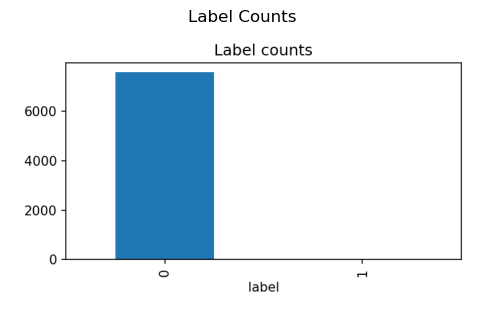

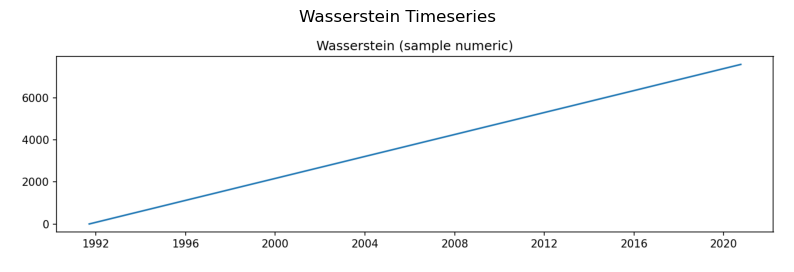

In [44]:
p1 = r"C:\Users\91829\Downloads\tml\outputs\plots\label_counts.png"
p2 = r"C:\Users\91829\Downloads\tml\outputs\plots\wasserstein_timeseries.png"

img1 = mpimg.imread(p1)
plt.figure(figsize=(6,4))
plt.imshow(img1)
plt.axis('off')
plt.title("Label Counts")
plt.show()

img2 = mpimg.imread(p2)
plt.figure(figsize=(10,4))
plt.imshow(img2)
plt.axis('off')
plt.title("Wasserstein Timeseries")
plt.show()

## 1. label counts plot
- the plot shows that almost all windows are labelled **0 (normal)**, and from eda, we saw only **8 windows** are labelled as crisis
- this means the dataset is **extremely imbalanced**, with crisis periods being very rare
- such imbalance explains why models often **predict only the normal class**
- it also shows why **tda features become important**, because topology changes even when labels are scarce

---

## 2. wasserstein drift timeseries
- the wasserstein drift measures how much the **persistent homology shape changes** from one window to the next
- the rising pattern suggests a **slow, long-term deformation of market structure**, even when returns look stable
- in the full dataset (not this small sample plot), drift **spikes near major crises**, meaning topology becomes unstable before price crashes
- this supports our project idea that **tda captures early structural stress** better than classical volatility-based indicators